# Machine Learning Lab - Experiment 6

## K Means Clustering - ImageCompression

### Aim

Use K-Means clustering for image compression by reducing the image color palette.

In [3]:
# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.cluster import KMeans

import kagglehub

In [4]:
# ------------------------------------------------------------
# 2. Download the Fruits Dataset
# ------------------------------------------------------------

path = kagglehub.dataset_download(
    "shreyapmaher/fruits-dataset-images"
)

print("Path to dataset files:")
print(path)

Using Colab cache for faster access to the 'fruits-dataset-images' dataset.
Path to dataset files:
/kaggle/input/fruits-dataset-images


In [5]:
# ------------------------------------------------------------
# 3. Locate an image from the downloaded dataset
# ------------------------------------------------------------

image_exts = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

image_paths = []

for root, dirs, files in os.walk(path):

    for file in files:

        if os.path.splitext(file)[1].lower() in image_exts:

            image_paths.append(
                os.path.join(root, file)
            )

if not image_paths:
    raise FileNotFoundError(
        "No image found in the downloaded dataset."
    )

print("Number of images found:", len(image_paths))

# Select the first image
image_path = image_paths[0]

print("Using image:")
print(image_path)

Number of images found: 359
Using image:
/kaggle/input/fruits-dataset-images/images/apple fruit/Image_22.jpg


In [6]:
# ------------------------------------------------------------
# 4. Load the image
# ------------------------------------------------------------

img = Image.open(image_path).convert("RGB")

print("Original image size:", img.size)

Original image size: (1200, 900)


In [7]:
# ------------------------------------------------------------
# 5. Resize image to exactly 396 x 396
# ------------------------------------------------------------

img = img.resize((396, 396))

img = np.array(img)

print("Image shape:", img.shape)

Image shape: (396, 396, 3)


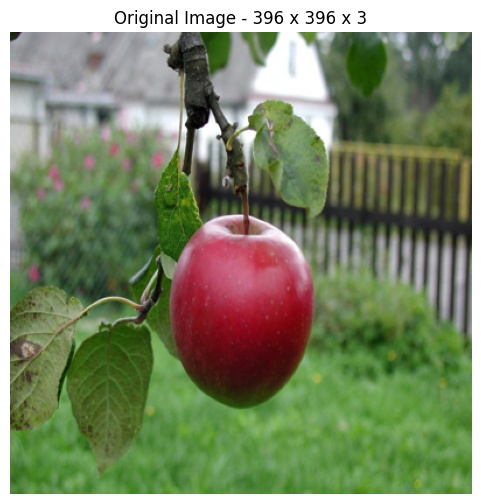

In [8]:
# ------------------------------------------------------------
# 6. Display the original image
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title("Original Image - 396 x 396 x 3")

plt.axis("off")

plt.show()

In [9]:
# ------------------------------------------------------------
# 7. Convert image into pixel data
# ------------------------------------------------------------

pixels = img.reshape(-1, 3).astype(np.float32)

print("Pixel data shape:", pixels.shape)

Pixel data shape: (156816, 3)


In [10]:
# ------------------------------------------------------------
# 8. Apply K-Means clustering
# ------------------------------------------------------------

k = 8

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

print("K-Means clustering completed.")

K-Means clustering completed.


In [11]:
# ------------------------------------------------------------
# 9. Create compressed image
# ------------------------------------------------------------

labels = kmeans.labels_

cluster_centers = kmeans.cluster_centers_

compressed_pixels = cluster_centers[labels]

compressed = compressed_pixels.reshape(
    396,
    396,
    3
)

compressed = np.clip(
    compressed,
    0,
    255
).astype(np.uint8)

print("Compressed image shape:", compressed.shape)

Compressed image shape: (396, 396, 3)


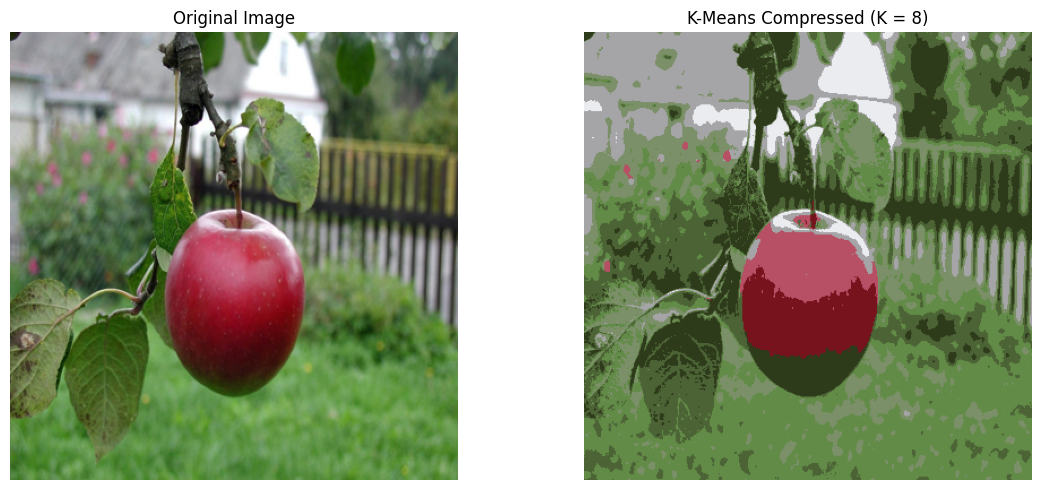

In [12]:
# ------------------------------------------------------------
# 10. Compare original and compressed images
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")


# Compressed image
plt.subplot(1, 2, 2)

plt.imshow(compressed)

plt.title("K-Means Compressed (K = 8)")

plt.axis("off")

plt.tight_layout()

plt.show()

In [13]:
# ------------------------------------------------------------
# 11. Compare number of colors
# ------------------------------------------------------------

original_colors = len(
    np.unique(
        img.reshape(-1, 3),
        axis=0
    )
)

print("Original number of colors:", original_colors)

print("Compressed palette size:", k)

Original number of colors: 107038
Compressed palette size: 8


In [14]:
# ------------------------------------------------------------
# 12. Save the compressed image
# ------------------------------------------------------------

output_path = "compressed_kmeans.png"

Image.fromarray(compressed).save(output_path)

print("Compressed image saved as:", output_path)

Compressed image saved as: compressed_kmeans.png
